In [1]:
import os
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import tifffile
import napari
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


### work in progress code to evaluate new tracking and exrtaction

In [2]:
def stack_to_kymograph(stack):
    """
    takes a numpyarray of an image in the format (t, y, x) and converts it into a kymograph
    """

    kymograph_gray = []
    for i in range(stack.shape[0]):
        frame = stack[i]
        if frame.ndim == 3:
            kymograph_gray.append(frame, axis=2)
        else:
            kymograph_gray.append(frame)
    
    kymograph = np.concatenate(kymograph_gray, axis =1)
    return kymograph

In [3]:
# code needed to help trim tif stacks
def get_tiff_frame_count(file_path):
	"""
	Reads a TIFF file using imread and returns the index of the last time frame (T - 1).
	NOTE: This loads the entire file into memory.
	"""
	try:
		# Load the entire image stack into memory
		img_stack = tifffile.imread(file_path)

		shape = img_stack.shape

		# Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1
			return shape[0] - 1
		else:
			# Single 2D image
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph):
    t, y, x = imgs.shape
    
    # Transpose to (y, t, x) then reshape to (y, t*x)
    kymo_imgs = imgs.transpose(1, 0, 2).reshape(y, -1)  # (400, 540)
    kymo_masks = ctc_masks.transpose(1, 0, 2).reshape(y, -1)

    kymo_tracks = napari_tracks.copy()
    # New x position: time_frame * width + original_x
    new_x = napari_tracks[:, 1] * x + napari_tracks[:, 3]
    kymo_tracks = np.column_stack([
        napari_tracks[:, 0],  # track_id
        np.zeros(len(napari_tracks)),  # dummy time (all in same frame)
        napari_tracks[:, 2],  # y stays the same
        new_x  # new x position
    ])

    v = napari.Viewer()
    v.add_image(kymo_imgs, name='kymograph')
    v.add_labels(kymo_masks, name='masks_kymo')
    v.add_tracks(data=kymo_tracks, graph=napari_tracks_graph, name='tracks_kymo')

def trim_stacks(time_dict, base_path):
    base_path =f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing'

    time_range_dict = json.loads(time_dict)
    # print(len(time_range_dict))
    phase_c_str = '0'
    fluor_c_str = '1'

    for folder, fov_dict in time_range_dict.items():    
        for fov_id in fov_dict.keys():
            trench_time_ranges = fov_dict[fov_id]
            print(f"  FOV: {fov_id}, Trenches: {list(trench_time_ranges.keys())}")

            for peak_id, time_info in trench_time_ranges.items():
                base_file_path = os.path.join(base_path, folder, 'hyperstacked', 'drift_corrected', 'rotated',
                                                'mm_channels', 'subtracted')
                path_to_phase_stack = os.path.join(base_file_path,
                                                    f'subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_c_str}.tif')
                path_to_labeled_stack = os.path.join(base_file_path,
                                                        f'mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_c_str}.tif')
                path_to_fluor_stack = os.path.join(base_file_path,
                                                    f'subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_c_str}.tif')
                # --- Dynamic Time Range Assignment ---
                start = time_info['start']
                end = time_info.get('end') 
            
                if end is None:
                    # Calculate end frame dynamically using the Phase stack file
                    end = get_tiff_frame_count(path_to_phase_stack)
                    if end == 0:
                        print(f"    WARNING: Could not determine frame count for {peak_id}. Skipping.")
                        continue

                # 2. Read Image Stacks
                try:
                    stack_phase = tifffile.imread(path_to_phase_stack)
                    stack_labeled = tifffile.imread(path_to_labeled_stack)
                    stack_fluor = tifffile.imread(path_to_fluor_stack)
                except FileNotFoundError as e:
                    print(f"    WARNING: Required file not found for {peak_id}: {e}. Skipping.")
                    continue
                # here is where I need to incorporate start and end
                print(start)
                print(end) 
                stack_phase_trimmed = stack_phase[start:end, :, :].copy()
                stack_labeled_trimmed = stack_labeled[start:end, :, :].copy()   
                return stack_phase_trimmed, stack_labeled_trimmed        

In [4]:
def compare_masks(old_kymo, new_kymo, phase_kymo):
    tab20_cmap = plt.get_cmap("tab20")
    colored_mask_old = np.zeros((*old_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(old_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (old_kymo == label)
            colored_mask_old[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_old[mask_indices, 3] = 1.0 
    colored_mask_new = np.zeros((*new_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(new_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (new_kymo == label)
            colored_mask_new[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_new[mask_indices, 3] = 1.0 
    
    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_old, alpha=0.5)  
    plt.title(f'Mask old')
    plt.axis('off')

    plt.show()

    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_new, alpha=0.5)  
    plt.title(f'Mask new')
    plt.axis('off')

    plt.show()   
    
    


In [ ]:
# this code loads up all of our datasets, note that it is not needed for track_astra 
path_all_lineages_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/tracked_all_cell_data_aggregate_032626.pkl'
path_all_cell_data_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/all_cell_data_aggregate_032626.pkl'
all_lineages_df = pd.read_pickle(path_all_lineages_df)
all_cell_data_df = pd.read_pickle(path_all_cell_data_df)

# code to establish some trouble shooting. Experiment_name can be changed to trouble shoot different experiments 
experiment = 'DUMM_gitg068_baeS_100225'
base_path =f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
path_to_phase_stack_dir=f'{base_path}'
path_to_labels_stack_dir =f'{base_path}/mask_kymos'
phase_list = os.listdir(path_to_phase_stack_dir)
mask_list =os.listdir(path_to_labels_stack_dir)

In [8]:
path_new_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/napari_corrections/020_589_corrected.tif'
path_old_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_020_region_589_c_0.tif'
path_to_phase_stack = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_020_region_589_c_0.tif'

In [9]:
phase_kymo = stack_to_kymograph(tifffile.imread(path_to_phase_stack))
mask_kymo_old=stack_to_kymograph(tifffile.imread(path_old_mask))
mask_kymo_new=stack_to_kymograph(tifffile.imread(path_new_mask))
tab20_cmap = plt.get_cmap("tab20")

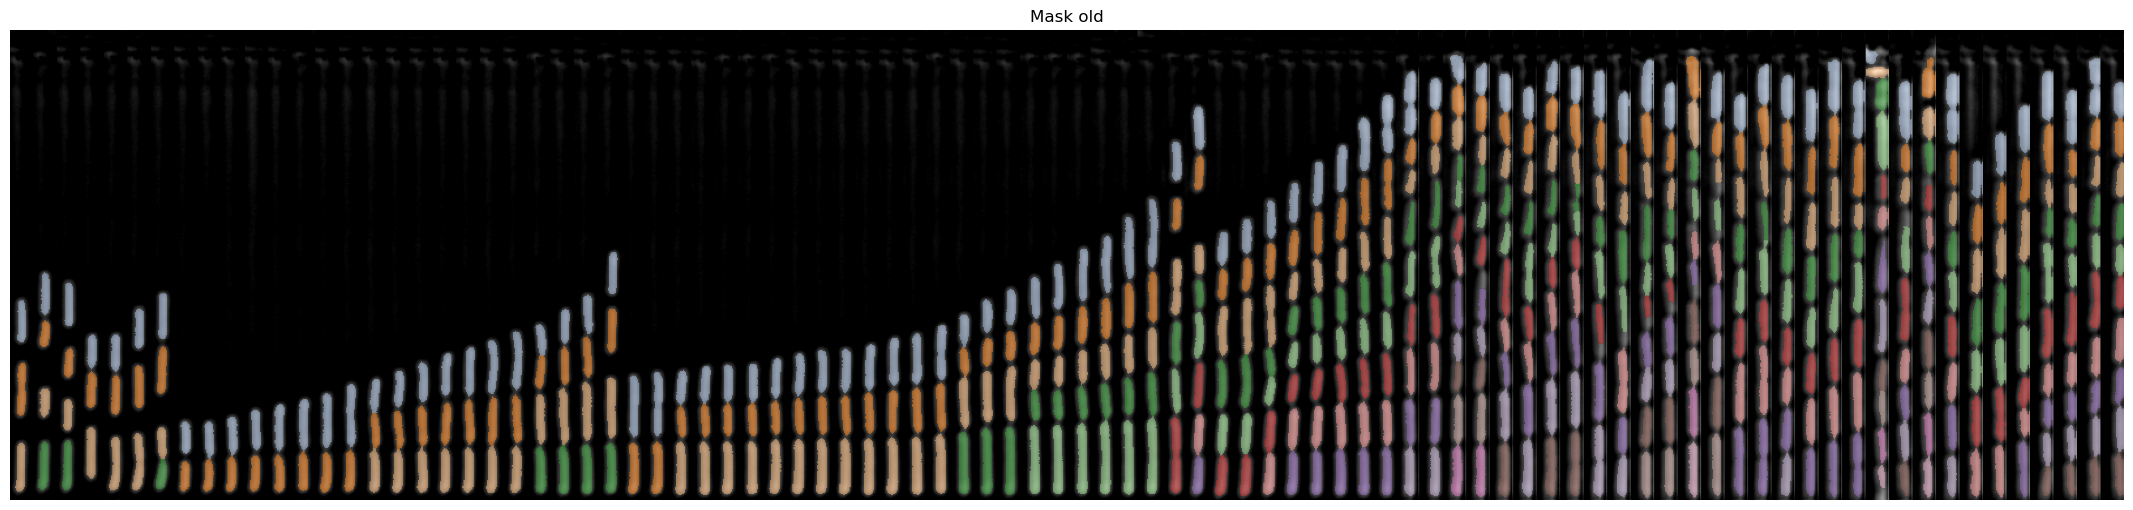

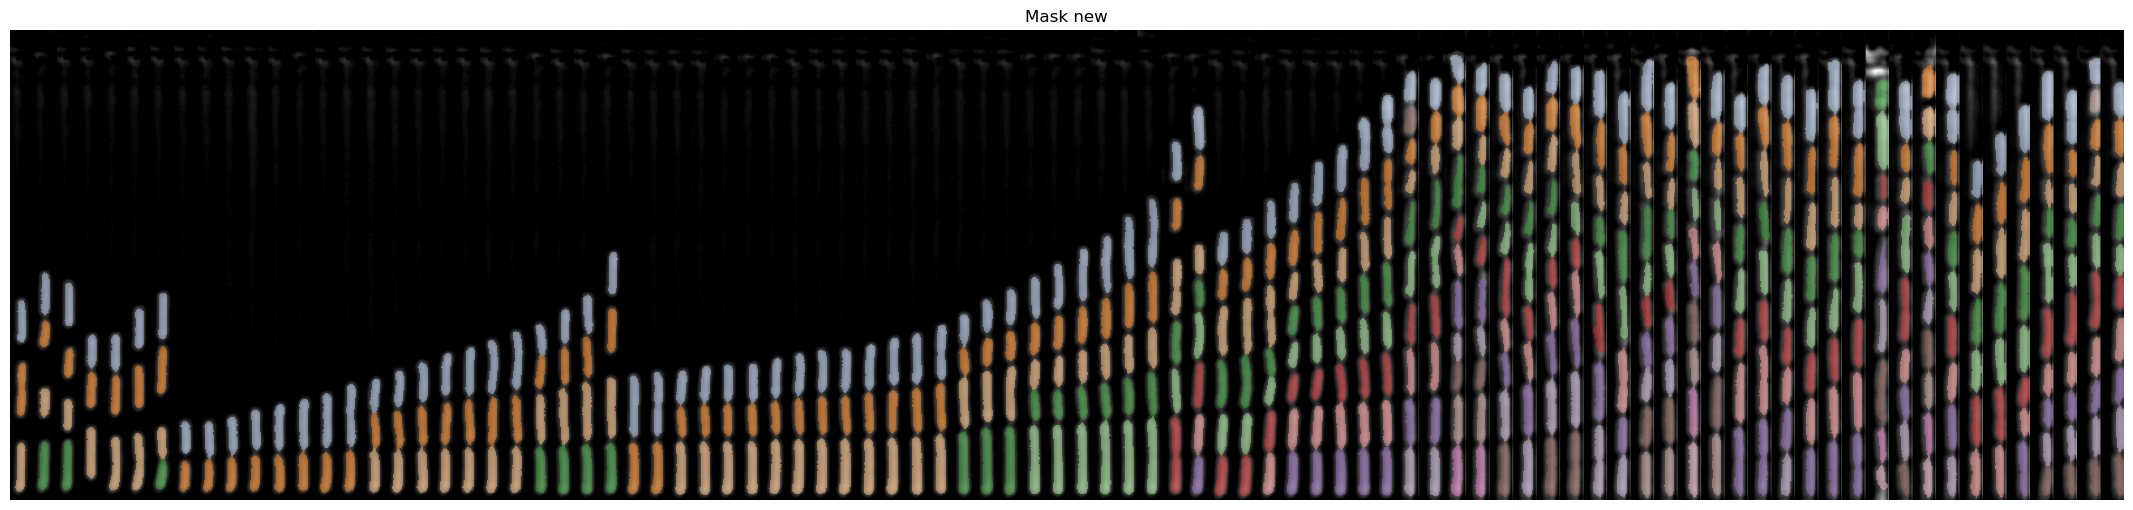

In [10]:
compare_masks(mask_kymo_old, mask_kymo_new, phase_kymo)

In [18]:
# load all data, note that path files may need to be updated
imgs = np.load('/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_imgs_020_589.npy')
napari_tracks = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_napari_tracks_020_589.npy")
ctc_masks = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_ctc_masks_020_589.npy")


with open("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_napari_tracks_graph_020_589.json") as f:
    napari_tracks_graph = json.load(f)
# (optional) convert keys/values back to int if needed:
napari_tracks_graph = {int(k): int(v) for k, v in napari_tracks_graph.items()}

In [16]:
imgs2 = np.load('/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/lacZ_legacySegmentation/DUMM_giTG059_068_SC_093025_imgs_020_589.npy')
napari_tracks2 = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/lacZ_legacySegmentation/DUMM_giTG059_068_SC_093025_napari_tracks_020_589.npy")
ctc_masks2 = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/lacZ_legacySegmentation/DUMM_giTG059_068_SC_093025_ctc_masks_020_589.npy")


with open("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/lacZ_legacySegmentation/DUMM_giTG059_068_SC_093025_napari_tracks_graph_020_589.json") as f:
    napari_tracks_graph2 = json.load(f)
# (optional) convert keys/values back to int if needed:
napari_tracks_graph2 = {int(k): int(v) for k, v in napari_tracks_graph2.items()}

In [19]:
plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph)

In [17]:
plot_trackastra_kymograph(imgs2, ctc_masks2, napari_tracks2, napari_tracks_graph2)

#Code to begin looking at outputs of trackasrta extraction

In [4]:
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

def merge_dicts(dict1, dict2):
    merged = defaultdict(dict)
    
    for key in dict1.keys():
        if key in dict2:
            # Merge if key exists in both dictionaries
            for subkey, values in dict1[key].items():
                if subkey in dict2[key]:
                    # Combine the lists for subkey
                    merged[key][subkey] = list(set(values + dict2[key][subkey]))
                else:
                    merged[key][subkey] = values
            for subkey, values in dict2[key].items():
                if subkey not in merged[key]:
                    merged[key][subkey] = values
        else:
            merged[key] = dict1[key]
    
    for key in dict2.keys():
        if key not in merged:
            merged[key] = dict2[key]
    
    return dict(merged)

In [5]:
strain_exp_dict = {
"chpS":{"DUMM_giTG62_Glucose_012925": ["005"],
        "DUMM_alkA_chpS_111325": ["003", "005", "006", "007", "009", "010", "011"]}, "baeS":{"DUMM_giTG66_Glucose_012325": ["003"]},  
"lacZ":{"DUMM_giTG059_noKan_Glucose_031125": ["004"],
        "DUMM_giTG059_060_061125": ["008"]},
"gfcE": {"DUMM_giTG064_Glucose_022625": ["001", "015"]},
"gldA": {"DUMM_giTG69_Glucose_013025": ["007"]},
"alkA": {"DUMM_giTG068_063_061725_v2": ["000"],
        "DUMM_giTG63_giTG67_Glucose_121724_1_v2": ["005"],
        "DUMM_alkA_chpS_111325": ["017","018","022", "023"]},
"mazF": {"DUMM_giTG059_060_061125": ["015"]}, 
"hupA":{"DUMM_giTG068_052925": ["005"], 
        "DUMM_giTG068_063_061725": ["012"]},
"araB": {"DUMM_CL008_giTG061_081225": ["015", "016", "017", "018", "019", "020"]},
}

strain_exp_dict_2 = {
  "chpS": {
    "DUMM_giTG062_064_121325": ["005", "010", "012"]
  },
  "baeS": {
    "DUMM_gitg068_baeS_100225": ["013", "017", "018", "019", "020", "021", "022", "023"],
    "DUMM_baeS_gfcE_112025": ["005"],
    "DUMM_giTG066_063_120925": ["002", "007"]
  },
  "gfcE": {
    "DUMM_baeS_gfcE_112025": ["011", "012", "016"],
    "DUMM_giTG062_064_121325": ["015", "019"],
    "DUMM_giTG060_064_121425": ["013", "014", "020", "022"]
  },
  "gldA": {
    "DUMM_giTG069_063_121125": ["013", "016", "022", "025"],
    "DUMM_giTG069_063_121225": ["013", "018", "022"]
  },
  "alkA": {
    "DUMM_giTG066_063_120925": ["018", "019"],
    "DUMM_giTG069_063_121125": ["001", "005", "006", "008"],
    "DUMM_giTG069_063_121225": ["000"]
  },
  "mazF": {
    "DUMM_giTG060_064_121425": ["000", "005"],
    "DUMM_mazF_murQ_121625": ["005", "006", "012"]
  },
  "murQ": {
    "DUMM_mazF_murQ_121625": ["017", "018"]
  }
}

strain_exp_dict_3={
"lacZ":{"DUMM_giTG059_068_SC_093025": ["015", "020"]
    },
"araB": {"CL008_giTG068_072925": ["003", "007", "009"]
    }
}

minutes_interval = {"DUMM_giTG62_Glucose_012925":5,
"DUMM_giTG66_Glucose_012325":5,
"DUMM_giTG059_noKan_Glucose_031125":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG064_Glucose_022625":5,
"DUMM_giTG69_Glucose_013025":5,
"DUMM_giTG068_063_061725_v2":10,
"DUMM_giTG63_giTG67_Glucose_121724_1_v2":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG068_052925":5,
"DUMM_giTG068_063_061725":10,
"DUMM_CL008_giTG061_081225":10,
"DUMM_alkA_chpS_111325":10,
"DUMM_giTG062_064_121325":10,
"DUMM_gitg068_baeS_100225":10,
"DUMM_baeS_gfcE_112025":10,
"DUMM_giTG066_063_120925":10,
"DUMM_giTG060_064_121425":10,
"DUMM_giTG069_063_121125":10,
"DUMM_giTG069_063_121225":10,
"DUMM_mazF_murQ_121625":10,
"DUMM_giTG059_068_SC_093025":10,
"CL008_giTG068_072925":10
}

combined_dict1 = merge_dicts(strain_exp_dict, strain_exp_dict_2)
combined_dict = merge_dicts(combined_dict1, strain_exp_dict_3)



In [6]:
exposure_dict= {'CL008_giTG068_072925': [45, 150],
'DUMM_alkA_chpS_111325': [120, 150],
'DUMM_baeS_gfcE_112025': [120, 150],
'DUMM_CL008_giTG061_081225': [120, 150],
'DUMM_giTG059_060_061125': [250, 250],
'DUMM_giTG059_068_SC_093025': [120, 150],
'DUMM_giTG059_noKan_Glucose_031125': [250, 450],
'DUMM_giTG060_064_121425': [120, 150],
'DUMM_giTG062_064_121325': [120, 150],
'DUMM_giTG064_Glucose_022625': [250, 500],
'DUMM_giTG066_063_120925': [120, 150],
'DUMM_giTG068_052925': [250, 450],
'DUMM_giTG068_063_061725': [45, 150],
'DUMM_gitg068_baeS_100225': [120, 150],
'DUMM_giTG069_063_121125': [120, 150],
'DUMM_giTG069_063_121225': [120, 150],
'DUMM_giTG66_Glucose_012325': [250, 500],
'DUMM_giTG69_Glucose_013025': [250, 500],
'DUMM_mazF_murQ_121625': [120, 150],
'DUMM_giTG068_063_061725_v2': [45, 150],
'DUMM_giTG63_giTG67_Glucose_121724_1_v2': [250, 500],
'DUMM_giTG62_Glucose_012925': [250, 500]
}

In [7]:
#load data files together 
tracked_all_cells_filename1 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/20250829_tracked_all_cell_data.pkl'
tracked_all_cells_filename2 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data031625.pkl'
tracked_all_cells_filename3 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data_120125.pkl'
tracked_all_cells_filename4 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data_032026.pkl'

# Read in the DataFrames
df1 = pd.read_pickle(tracked_all_cells_filename1)
df2 = pd.read_pickle(tracked_all_cells_filename2)
df3 = pd.read_pickle(tracked_all_cells_filename3)
df4 = pd.read_pickle(tracked_all_cells_filename4)

df1['unique_node_id'] = 'df1_' + df1['node_id'].astype(str)
df2['unique_node_id'] = 'df2_' + df2['node_id'].astype(str)
df3['unique_node_id'] = 'df3_' + df3['node_id'].astype(str)
df4['unique_node_id'] = 'df4_' + df4['node_id'].astype(str)

all_lineages_df = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
all_lineages_temp = all_lineages_df.copy()


In [8]:
lineages_lacZ = all_lineages_temp[all_lineages_temp['experiment_name'] == 'DUMM_giTG059_068_SC_093025']

Loaded 5371 cell-frame rows
Experiments : ['DUMM_giTG059_068_SC_093025']
Genes       : ['lacZ']
FOVs        : ['015' '020']
Trenches    : ['228' '379' '681' '756' '831' '1284' '1586' '1963' '62' '514' '589' '665'
 '815' '1117' '1865']
Lineages    : 592  |  Unique tracks: 0
Total lineages found      : 1847
Lineages with ≥1 burst    : 95  (5.1%)
Total burst frames        : 234

Unique tracks per lineage:
n_tracks
0    1847


/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_33634/2900836848.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


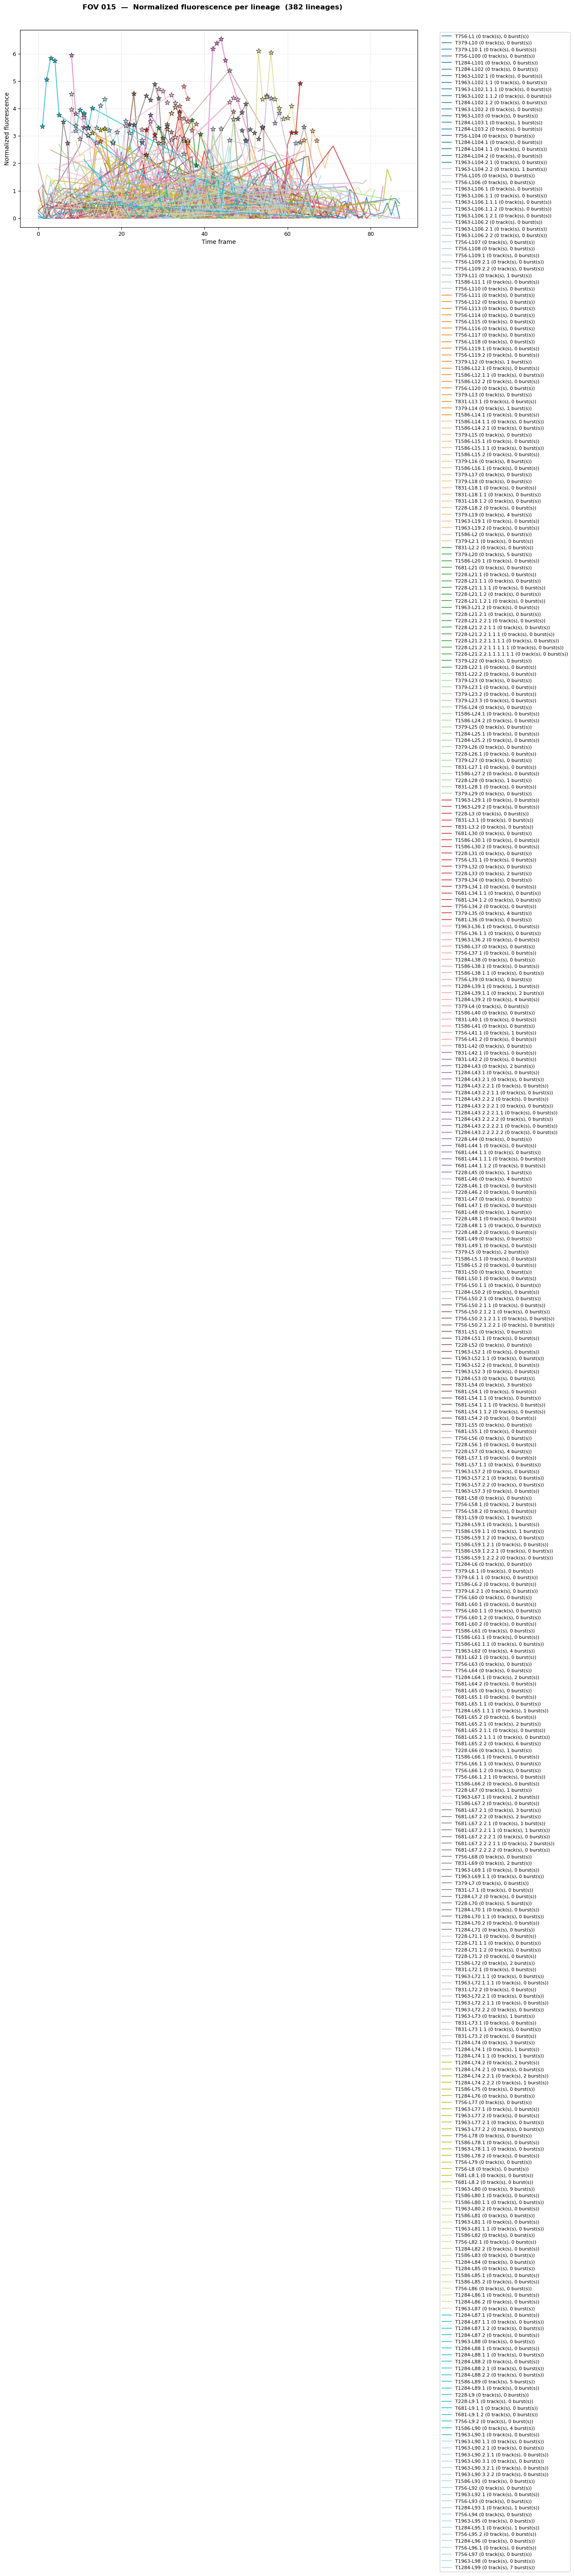

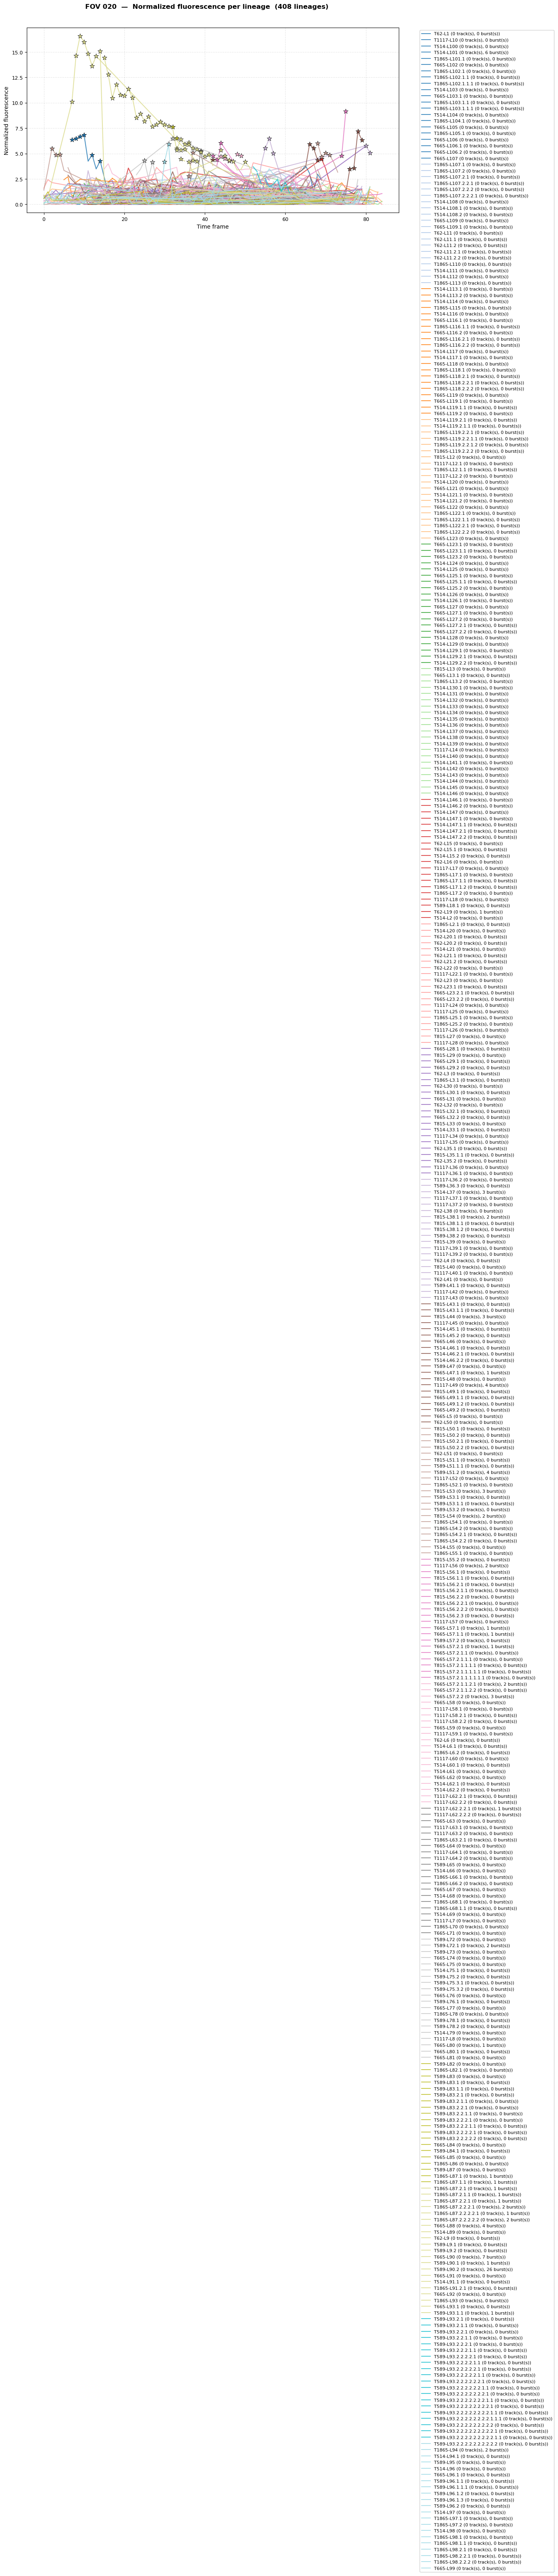

In [9]:
# --- Load the trackastra feature extraction output ---
# Update this path to wherever 06_trackastra_feature_extraction.py saved the pkl

df = lineages_lacZ

# detect_fluorescence_bursts_by_group groups by ['gene', 'experiment_name', 'FOV'].
# Add the gene column here if it wasn't set during extraction.
# Change the value to match the actual strain/gene label for this experiment.
if 'gene' not in df.columns:
    df['gene'] = 'giTG059_068'

print(f"Loaded {len(df)} cell-frame rows")
print(f"Experiments : {df['experiment_name'].unique()}")
print(f"Genes       : {df['gene'].unique()}")
print(f"FOVs        : {df['FOV'].unique()}")
print(f"Trenches    : {df['trench_id'].unique()}")
print(f"Lineages    : {df['predicted_lineage'].nunique()}  |  Unique tracks: {df['track_id'].nunique()}")

# --- Run burst detection ---
# Uses detect_fluorescence_bursts_by_group defined in an earlier cell.
# That function groups by ['gene', 'experiment_name', 'FOV'] and adds:
#   normalized_fluorescence  -- baseline-subtracted signal
#   is_burst                 -- True on frames that are local peaks above threshold

df_bursts = detect_fluorescence_bursts_by_group(
    df,
    fluor_col='intensity_mean_fluor',
    rolling_window_size=6,
    std_dev_threshold=2,
)

# --- Summary: lineages, unique cells, burst counts ---

# Unique cells (track segments) per lineage
cells_per_lineage = (
    df_bursts.groupby(['FOV', 'trench_id', 'predicted_lineage'])['track_id']
    .nunique()
    .reset_index(name='n_tracks')
)

# Burst frames per lineage
bursts_per_lineage = (
    df_bursts[df_bursts['is_burst']]
    .groupby(['FOV', 'trench_id', 'predicted_lineage'])
    .size()
    .reset_index(name='n_burst_frames')
)

lineage_summary = cells_per_lineage.merge(bursts_per_lineage, on=['FOV', 'trench_id', 'predicted_lineage'], how='left')
lineage_summary['n_burst_frames'] = lineage_summary['n_burst_frames'].fillna(0).astype(int)
lineage_summary['has_burst'] = lineage_summary['n_burst_frames'] > 0

n_lineages     = lineage_summary.shape[0]
n_with_bursts  = lineage_summary['has_burst'].sum()
total_bursts   = lineage_summary['n_burst_frames'].sum()

print(f"Total lineages found      : {n_lineages}")
print(f"Lineages with ≥1 burst    : {n_with_bursts}  ({100*n_with_bursts/n_lineages:.1f}%)")
print(f"Total burst frames        : {total_bursts}")
print(f"\nUnique tracks per lineage:")
print(lineage_summary['n_tracks'].value_counts().sort_index().rename('n_lineages').to_string())
lineage_summary.head(10)

# --- Fluorescence intensity over time, all lineages per FOV on one plot ---
# normalized_fluorescence is the baseline-subtracted signal from detect_fluorescence_bursts_by_group.
# Burst frames are highlighted with markers.

fluor_col = 'normalized_fluorescence'

# Generate a color palette for lineages
import matplotlib.cm as cm
import numpy as np

for fov, fov_df in df_bursts.groupby('FOV'):
    # Get all unique lineages in this FOV (across all trenches)
    lineages = sorted(fov_df['predicted_lineage'].unique())
    n_lineages = len(lineages)
    
    if n_lineages == 0:
        continue
    
    # Create color map
    colors = cm.tab20(np.linspace(0, 1, n_lineages))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(f'FOV {fov}  —  Normalized fluorescence per lineage  ({n_lineages} lineages)', 
                 fontsize=12, fontweight='bold')
    
    for idx, lineage_id in enumerate(lineages):
        lin_df = (
            fov_df[fov_df['predicted_lineage'] == lineage_id]
            .sort_values('time_frame')
        )
        
        # Aggregate per time frame (mean across any overlapping track segments)
        ts = lin_df.groupby('time_frame')[fluor_col].mean()
        
        # Get trench info for label
        trench_id = lin_df['trench_id'].iloc[0]
        n_tracks = lin_df['track_id'].nunique()
        n_bursts = lin_df['is_burst'].sum()
        
        label = f'T{trench_id}-L{lineage_id} ({n_tracks} track(s), {n_bursts} burst(s))'
        
        # Plot the lineage trace
        ax.plot(ts.index, ts.values, color=colors[idx], lw=1.5, label=label, alpha=0.8)
        
        # Mark burst frames with scatter points
        burst_frames = lin_df[lin_df['is_burst']]['time_frame'].values
        if len(burst_frames) > 0:
            burst_values = [ts.loc[t] if t in ts.index else np.nan for t in burst_frames]
            ax.scatter(burst_frames, burst_values, color=colors[idx], 
                      s=80, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    
    ax.set_xlabel('Time frame', fontsize=10)
    ax.set_ylabel('Normalized fluorescence', fontsize=10)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.show()

In [19]:
def add_gene_column(df, strain_dict):
      # Initialize gene column with None or empty string
    df['gene'] = None
    
    # Create a reverse lookup dictionary for faster matching
    # Structure: {(experiment_name, FOV): gene}
    lookup = {}
    for gene, experiments in strain_dict.items():
        for exp_name, fov_list in experiments.items():
            if exp_name != "experiment_name":  # Skip the metadata key
                for fov in fov_list:
                    lookup[(exp_name, fov)] = gene
    
    # Match and update the gene column
    for idx, row in df.iterrows():
        exp_name = row['experiment_name']
        fov = str(row['FOV']).zfill(3) if 'FOV' in df.columns else None
        
        if fov and (exp_name, fov) in lookup:
            df.at[idx, 'gene'] = lookup[(exp_name, fov)]
    
    return df

# Usage
lineages_leg = add_gene_column(legacy_seg, combined_dict)
lineages_new = add_gene_column(new_seg, combined_dict)

#plot mean phase and fluor intensity 

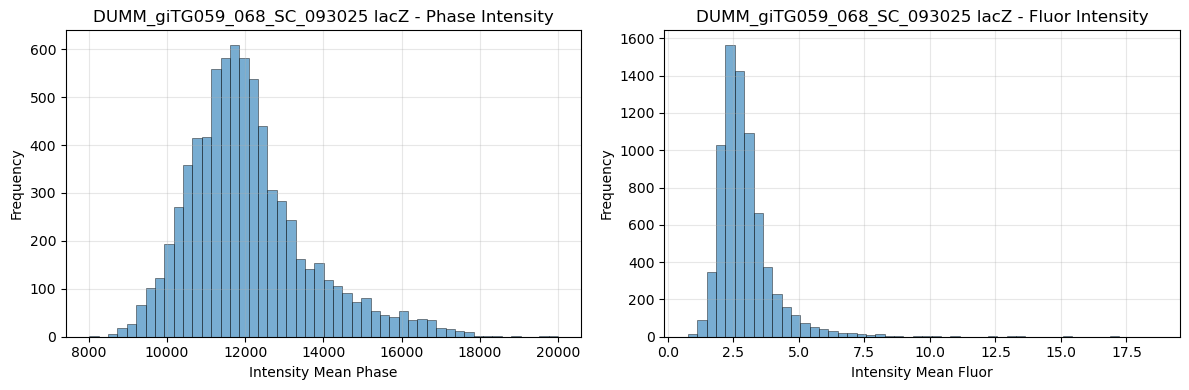

In [ ]:
# Create subplots - 2 columns (one for each intensity type)
n_experiments = len(experiments_leg)
fig, axes = plt.subplots(n_experiments, 2, figsize=(12, 4*n_experiments))

# Handle case where there's only one experiment
if n_experiments == 1:
    axes = axes.reshape(1, -1)

for idx, experiment in enumerate(experiments_leg):
    # Filter data for this experiment and remove None genes
    exp_data = lineages_leg[lineages_leg['experiment_name'] == experiment]
    # exp_data = exp_data[exp_data['gene'].notna() & (exp_data['gene'] != 'none') & (exp_data['gene'] != 'None')]
    
    # Get unique genes for this experiment
    genes = exp_data['gene'].unique()
    
    # Define colors for different genes
    colors = plt.cm.tab10(np.linspace(0, 1, len(genes)))
    
    # Plot intensity_mean_phase
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 0].hist(gene_data['intensity_mean_phase'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 0].set_xlabel('Intensity Mean Phase')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{experiment} {gene} - Phase Intensity')
    axes[idx, 0].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 0].legend()
    
    # Plot intensity_mean_fluor
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 1].hist(gene_data['intensity_mean_fluor'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 1].set_xlabel('Intensity Mean Fluor')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{experiment} {gene} - Fluor Intensity')
    axes[idx, 1].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 1].legend()

plt.tight_layout()
plt.show()

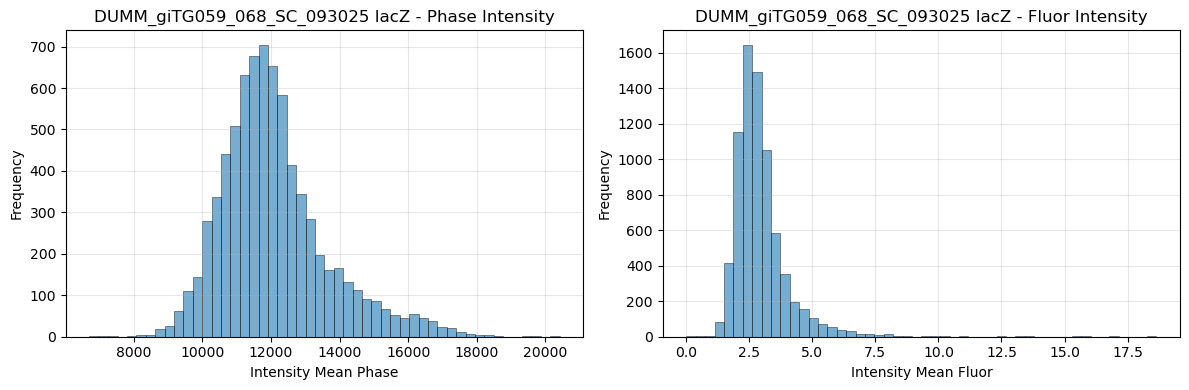

In [20]:
# Create subplots - 2 columns (one for each intensity type)
n_experiments = len(experiments_new)
fig, axes = plt.subplots(n_experiments, 2, figsize=(12, 4*n_experiments))

# Handle case where there's only one experiment
if n_experiments == 1:
    axes = axes.reshape(1, -1)

for idx, experiment in enumerate(experiments_new):
    # Filter data for this experiment and remove None genes
    exp_data = lineages_new[lineages_new['experiment_name'] == experiment]
    # exp_data = exp_data[exp_data['gene'].notna() & (exp_data['gene'] != 'none') & (exp_data['gene'] != 'None')]
    
    # Get unique genes for this experiment
    genes = exp_data['gene'].unique()
    
    # Define colors for different genes
    colors = plt.cm.tab10(np.linspace(0, 1, len(genes)))
    
    # Plot intensity_mean_phase
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 0].hist(gene_data['intensity_mean_phase'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 0].set_xlabel('Intensity Mean Phase')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{experiment} {gene} - Phase Intensity')
    axes[idx, 0].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 0].legend()
    
    # Plot intensity_mean_fluor
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 1].hist(gene_data['intensity_mean_fluor'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 1].set_xlabel('Intensity Mean Fluor')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{experiment} {gene} - Fluor Intensity')
    axes[idx, 1].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 1].legend()

plt.tight_layout()
plt.show()

### the following plots histograms for phase/fluor for each gene with each experiment per gene 

In [ ]:
genes = ['chpS', 'baeS', 'lacZ', 'gfcE', 'gldA', 'alkA', 'mazF', 'hupA', 'araB', 'murQ']

filtered_df = lineages_new[
    lineages_new['gene'].notna() & 
    (lineages_new['gene'].astype(str).str.lower() != 'none')
]

for gene in genes:
    gene_data = filtered_df[filtered_df['gene'] == gene]
    
    if len(gene_data) == 0:
        print(f"No data for gene: {gene}")
        continue
    
    experiments = gene_data['experiment_name'].unique()
    n_experiments = len(experiments)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, n_experiments))
    
    # Plot intensity_mean_phase
    for exp_idx, experiment in enumerate(experiments):
        exp_data = gene_data[gene_data['experiment_name'] == experiment]
        
        # Get exposure info
        if experiment in exposure_dict:
            phase_exp = exposure_dict[experiment][0]
            label = f'{experiment} (exp: {phase_exp})'
        else:
            label = f'{experiment} (exp: N/A)'
        
        axes[0].hist(exp_data['intensity_mean_phase'].dropna(), bins=50, 
                     color=colors[exp_idx], alpha=0.6, 
                     label=label, edgecolor='black', linewidth=0.5)
    
    axes[0].set_xlabel('Intensity Mean Phase', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'{gene} - Phase Intensity (n={n_experiments} experiments)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot intensity_mean_fluor
    for exp_idx, experiment in enumerate(experiments):
        exp_data = gene_data[gene_data['experiment_name'] == experiment]
        
        # Get exposure info
        if experiment in exposure_dict:
            fluor_exp = exposure_dict[experiment][1]
            label = f'{experiment} (exp: {fluor_exp})'
        else:
            label = f'{experiment} (exp: N/A)'
        
        axes[1].hist(exp_data['intensity_mean_fluor'].dropna(), bins=50, 
                     color=colors[exp_idx], alpha=0.6, 
                     label=label, edgecolor='black', linewidth=0.5)
    
    axes[1].set_xlabel('Intensity Mean Fluor', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title(f'{gene} - Fluor Intensity (n={n_experiments} experiments)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.suptitle(f'Gene: {gene}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [24]:
### original code:
lineages_new['gene'] = None

# for each experiment this
for gene, exps_fov in combined_dict.items():
    for exp_view, fovs in exps_fov.items():
        mask = lineages_new['FOV'].isin(fovs) & (lineages_new['experiment_name'] == exp_view)
        lineages_new.loc[mask, 'gene'] = gene
        
bursts_all_lineages_df = detect_fluorescence_bursts_by_group(lineages_new,
                                                            fluor_col = 'intensity_mean_fluor',
                                                            rolling_window_size = 10,
                                                            std_dev_threshold = 3,
                                                            )

counts_per_lineage = bursts_all_lineages_df.groupby(['gene', 'experiment_name', 'FOV', 'trench_id']).size()

time_frames_per_avg_cell_cycle = counts_per_lineage.groupby(['gene', 'experiment_name']).mean().reset_index().rename(columns={0: 'average_frame_count'})
# First, calculate the number of peaks and unique cells for each gene/experiment combo.
grouped_data = bursts_all_lineages_df.groupby(['gene', 'experiment_name']).agg(
    num_peaks=('is_burst', 'sum'),  # Summing boolean 'is_burst' counts the True values
    num_cell_images=('node_id', pd.Series.nunique)
).reset_index()

# Second, merge this with the cell cycle length data
peak_freq_df = pd.merge(grouped_data, time_frames_per_avg_cell_cycle,
                        on=['gene', 'experiment_name'])
# Third, perform the final calculation
peak_freq_df['peak_frequency'] = (peak_freq_df['num_peaks'] / peak_freq_df['num_cell_images']) * peak_freq_df['average_frame_count']
avg_peak_freq_per_gene = peak_freq_df.groupby('gene')['peak_frequency'].mean().reset_index()


In [25]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
bursts_all_lineages_df['subgen'] = bursts_all_lineages_df.groupby(cols_use)['is_burst'].transform('any')

In [26]:
for gene in bursts_all_lineages_df['gene'].unique():
    print(gene)
    print(bursts_all_lineages_df['intensity_max_fluor'][bursts_all_lineages_df['gene'] == gene].describe())

lacZ
count    7556.000000
mean       14.378772
std         3.876450
min         0.000000
25%        12.000000
50%        14.000000
75%        16.000000
max        48.000000
Name: intensity_max_fluor, dtype: float64


In [27]:
mask_baseline_exp = (bursts_all_lineages_df['intensity_max_fluor']> 60) & (~bursts_all_lineages_df['subgen'])
bursts_all_lineages_df['subgen'][mask_baseline_exp] = True

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_95851/4147307789.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bursts_all_lineages_df['subgen'][mask_baseline_exp] = True
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipyke

In [28]:
bursts_all_lineages_df['time_interval_minutes'] = bursts_all_lineages_df['experiment_name'].map(minutes_interval)
bursts_all_lineages_df['time_minutes'] = bursts_all_lineages_df['time_interval_minutes'] * bursts_all_lineages_df['time_frame']

In [29]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
idx = bursts_all_lineages_df.groupby(cols_use)['time_minutes'].idxmin()

In [30]:
cell_first_appearance_df = bursts_all_lineages_df.loc[idx]
cell_first_appearance_df['mother_ids'] = cell_first_appearance_df['predicted_lineage'].str.split('.').str[0]

In [31]:
cells_sorted = cell_first_appearance_df.sort_values(
    by=['gene', 'experiment_name', 'FOV', 'trench_id', 'mother_ids', 'time_minutes'],
    ascending=True
).reset_index(drop=True)

In [32]:
cells_sorted.groupby('gene').count().iloc[:, 0]

gene
lacZ    963
Name: area, dtype: int64

In [33]:
def calculate_gaps_exp_experimental(df: pd.DataFrame) -> dict:
    """
    Calculates the length of consecutive runs of 'subgen' == False (non-expression)
    that are bounded by 'subgen' == True (expression) cells, allowing gaps
    that start at the first cell or end at the last cell of the gene's sequence.

    Args:
        df (pd.DataFrame): DataFrame with 'gene', 'subgen' columns.
                           Rows are expected to be ordered chronologically.

    Returns:
        dict: A dictionary where keys are gene names and values are lists of
              the lengths (in cells/rows) of the non-expression gaps found.
    """
    gene_non_expression_gaps = {}

    if df.empty:
        return {}

    grouped = df.groupby('gene')

    for gene, gene_df in grouped:
        # Get the first and last index of the current gene's sequence
        first_index = gene_df.index[0]
        last_index = gene_df.index[-1]

        # Invert 'subgen' to treat non-expression (False) as True for RLE grouping
        is_non_expression = (gene_df['subgen'] == False)

        # 1. Identify where a run of non-expression starts
        run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))

        # 2. Assign a unique ID to each consecutive run and calculate run lengths
        run_id = run_starts.cumsum()
        non_expression_groups = run_id[is_non_expression]

        if not non_expression_groups.empty:
            non_expression_groups.name = 'run_id'
            gap_lengths_df = non_expression_groups.groupby(non_expression_groups).size().reset_index(name='length')

            # 3. Get the start and end index of each run
            run_start_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).first()
            run_end_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).last()

            gap_lengths_df['start_index'] = gap_lengths_df['run_id'].map(run_start_indices)
            gap_lengths_df['end_index'] = gap_lengths_df['run_id'].map(run_end_indices)

            # 4. Apply the fully inclusive boundary conditions:

            # Condition A (Precursor Check): Preceded by Expression OR Starts at First Index
            preceded_by_exp = (gene_df['subgen'].shift(1).loc[gap_lengths_df['start_index']] == True).fillna(False).values
            starts_at_first = (gap_lengths_df['start_index'] == first_index).values
            preceded_ok = preceded_by_exp | starts_at_first

            # Condition B (Successor Check): Followed by Expression OR Ends at Last Index
            followed_by_exp = (gene_df['subgen'].shift(-1).loc[gap_lengths_df['end_index']] == True).fillna(False).values
            ends_at_last = (gap_lengths_df['end_index'] == last_index).values
            followed_ok = followed_by_exp | ends_at_last

            # 5. Final Valid Gaps: (Preceded OK) AND (Followed OK)
            valid_gaps = gap_lengths_df[preceded_ok & followed_ok]

            gene_non_expression_gaps[gene] = valid_gaps['length'].tolist()
        else:
            gene_non_expression_gaps[gene] = []

    return gene_non_expression_gaps

In [34]:
results = calculate_gaps_exp_experimental(cells_sorted)

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_95851/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))


In [35]:
def plot_average_gaps(protein_gaps_dict):
    """Calculates and plots the average gap lengths."""
    average_gaps = {}
    for protein, gaps in protein_gaps_dict.items():
        average = np.mean(gaps) if gaps else 0.0
        average_gaps[protein] = average

    df_avg = pd.DataFrame.from_dict(
        average_gaps, 
        orient='index', 
        columns=['Average Gap Length']
    ).sort_values(by='Average Gap Length', ascending=False)
    custom_order = ['lacZ', 'gldA', 'araB', 'murQ', 'alkA', 'gfcE', 'chpS', 'baeS', 'mazF', 'hupA']

    df_avg_ordered = df_avg.reindex(custom_order)

    plt.figure(figsize=(6, 6))
    bars = plt.bar(
        df_avg.index, 
        df_avg['Average Gap Length'],
        color='slateblue' 
    )

    plt.xlabel('Gene', fontsize=20)
    plt.ylabel('Average gap in expression \n (# generations)', fontsize=20)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca() 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

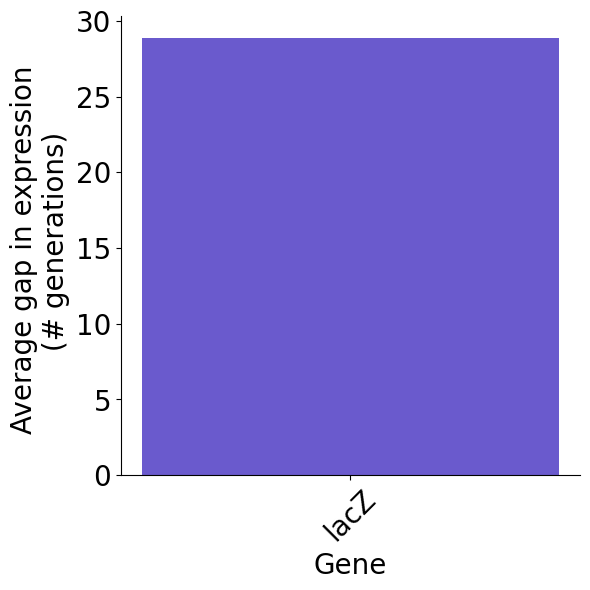

In [36]:
plot_average_gaps(results)